# v7 - three velocity fields, one construction: raw GLORYS vs `Fix_W` vs `poisson_b`

v5 established the sign of W and v6 established the construction: `FieldSet.from_nemo` applies
`W.set_scaling_factor(-1.0)` itself, so the stock `AdvectionRK4_3D` is the correct kernel and
reproduces v4's `negW` trajectories bit for bit. With the sign question closed, the remaining
question is the one the corrections were built to answer: **how much does the choice of velocity
field actually move the particles?**

Three fieldsets, identical seeds, identical dt and runtime, all through `from_nemo` +
`AdvectionRK4_3D`:

| tag | U, V | W | what is wrong with it |
|---|---|---|---|
| `glorys` | raw GLORYS | raw `vovecrtz` | W is not the W implied by U,V; `W(0) != 0` |
| `fix_w` | raw GLORYS | `vovecrtz` minus the surface kinematic taper | `W(0) = 0`, but U,V still divergent |
| `poisson_b` | rescaled + barotropic Poisson correction | rebuilt from the corrected U,V | closed by construction |

The three are nested: `glorys` has both defects, `fix_w` fixes the surface boundary condition
only, `poisson_b` fixes the column budget and rebuilds W from the result. Section 2 measures
those two defects directly on the data before any particle is released, so the trajectory
differences later can be attributed rather than guessed at.

## What to expect, stated before running

- **`glorys` should lose particles through the sea surface.** Its `W(0)` is not zero, and with
  the sign now correct a positive `W(0)` is upward motion at `z = 0`. Parcels raises
  `ErrorThroughSurface` there, and v4's `CheckError` kernel deletes rather than clamps, so the
  loss is recorded instead of hidden. The plume release sits at 0-10 m and is the exposed one.
- **`fix_w` should not.** `W(0) = 0` exactly by construction.
- **Horizontal spread should be dominated by U,V, not W.** `glorys` and `fix_w` share U and V
  and differ only in W, so their separation isolates the W correction; `poisson_b` is the only
  one with different U,V, so its separation from the other two carries the Poisson correction.
  If the `glorys`/`fix_w` pair separates as much as either does from `poisson_b`, that
  expectation is wrong and W matters more than assumed.

Sections 5-7 test all three. They are not adjusted afterwards.

## 1. Configuration

In [1]:
n_per_region       = 200
run_time_days      = 80
time_step_minutes  = 20
out_put_step_hours = 6

ref_date, offset = "1993-01-01", 1
rdm_seed = 110987
MONTHS = [1, 2, 3]

Hgr, Zgr = "Hgr_cmesh.nc", "Zgr_cmesh2.nc"

def mf(pat):
    return [pat.format(y=1993, m=m) for m in MONTHS]

FIELDSETS = {
    "glorys":    dict(U=mf("U_{y}-{m:02d}.nc"),  V=mf("V_{y}-{m:02d}.nc"),
                      W=mf("W_{y}-{m:02d}.nc")),
    "fix_w":     dict(U=mf("U_{y}-{m:02d}.nc"),  V=mf("V_{y}-{m:02d}.nc"),
                      W=mf("W_{y}-{m:02d}fc2.nc")),
    "poisson_b": dict(U=mf("U_{y}-{m:02d}b.nc"), V=mf("V_{y}-{m:02d}b.nc"),
                      W=mf("W_{y}-{m:02d}b.nc")),
}
TAGS = list(FIELDSETS)

SHELF_H    = (20.0, 100.0)
SHELF_BOX  = dict(lon=(-52, -46), lat=(-1.5, 4.5))
PLUME_LINE = dict(lon=(-49.916, -49.083), lat=(1.166, -0.0833), z=(0.0, 10.0))

out_root    = "tracks_v7"
FORCE_RERUN = False
DIAG_T      = 1                                    # daily record used for the field diagnostics
DIAG_SUB    = (slice(150, 300), slice(450, 700))   # interior window, away from the rim

In [2]:
import os, sys, shutil, contextlib, textwrap
import numpy as np
import xarray as xr
from datetime import timedelta
from scipy.spatial import cKDTree
import matplotlib as mpl
import matplotlib.pyplot as plt

import parcels
from parcels import (FieldSet, Field, ParticleSet, JITParticle, Variable,
                     AdvectionRK4_3D, StatusCode)

@contextlib.contextmanager
def quiet():
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1); yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)

print("parcels", parcels.__version__)
for tag, f in FIELDSETS.items():
    miss = [p for v in ("U", "V", "W") for p in f[v] if not os.path.exists(p)]
    print(f"  {tag:<10} {'OK' if not miss else 'MISSING: ' + ', '.join(miss)}")

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
nout = int(run_time_days * 24 / out_put_step_hours) + 1
print(f"\n{start_time} -> {start_time + np.timedelta64(run_time_days,'D')}"
      f"   dt={time_step_minutes} min   {nout} outputs")

parcels 3.1.2
  glorys     OK
  fix_w      OK
  poisson_b  OK

1993-01-02 -> 1993-03-23   dt=20 min   321 outputs


## 2. Grid, true seabed, seeds

Verbatim from v4, same `rdm_seed` and draw order, so the 400 release points match v4, v6 and
each other exactly. All three fieldsets get the same particles.

In [3]:
zgr = xr.open_dataset(Zgr).squeeze()
hgr = xr.open_dataset(Hgr).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")
e3t_ps  = zgr.e3t_ps.values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values.astype("f8"), zgr.nav_lat.values.astype("f8")
glamf, gphif = hgr.glamf.values.astype("f8"), hgr.gphif.values.astype("f8")
nz, ny, nx = len(gdepw_0), *mbathy.shape

kb    = np.clip(mbathy - 1, 0, nz - 1)
thick = np.where(mbathy > 0, e3t_ps, 0.0)
H     = gdepw_0[kb] + thick            # true seabed (bottom of the partial cell)
Gnom  = np.where(mbathy > 0, gdepw_0[np.clip(mbathy, 0, nz - 1)], 0.0)
#       ^ the depth Parcels assigns to the zero-w face at k=mbathy: the field's own floor
zbot  = gdepw_0[kb] + 0.5 * thick      # middle of the deepest wet cell

wj, wi = np.where(mbathy > 0)
tree   = cKDTree(np.column_stack([lon2d[wj, wi], lat2d[wj, wi]]))
Hw     = H[wj, wi]
def seabed_at(lo, la):
    f = np.column_stack([np.ravel(lo), np.ravel(la)]); ok = np.isfinite(f).all(1)
    o = np.full(len(f), np.nan)
    if ok.any(): o[ok] = Hw[tree.query(f[ok])[1]]
    return o.reshape(np.shape(lo))

rng = np.random.default_rng(rdm_seed)
shelf = ((mbathy > 0) & (H > SHELF_H[0]) & (H < SHELF_H[1])
         & (lon2d > SHELF_BOX["lon"][0]) & (lon2d < SHELF_BOX["lon"][1])
         & (lat2d > SHELF_BOX["lat"][0]) & (lat2d < SHELF_BOX["lat"][1]))
jj, ii = np.where(shelf)
sel = rng.choice(len(jj), size=n_per_region, replace=len(jj) < n_per_region)
bj, bi = jj[sel], ii[sel]
REL = {"bottom": (lon2d[bj, bi], lat2d[bj, bi], zbot[bj, bi])}

def seed_line(n, zlo, zhi):
    '''Draws that fall below the local seabed are discarded and redrawn, never moved.'''
    lo, la, zz = np.empty(n), np.empty(n), np.empty(n)
    got = drawn = 0
    while got < n:
        m = max(n - got, 16)
        t = rng.uniform(0, 1, m)
        cl = PLUME_LINE["lon"][0] + t * (PLUME_LINE["lon"][1] - PLUME_LINE["lon"][0])
        ca = PLUME_LINE["lat"][0] + t * (PLUME_LINE["lat"][1] - PLUME_LINE["lat"][0])
        cz = rng.uniform(zlo, zhi, m)
        ok = cz < seabed_at(cl, ca)
        k = min(int(ok.sum()), n - got)
        if k:
            lo[got:got+k], la[got:got+k], zz[got:got+k] = cl[ok][:k], ca[ok][:k], cz[ok][:k]
            got += k
        drawn += m
    print(f"  plume: discarded {drawn - got} of {drawn} draws below the seabed")
    return lo, la, zz

REL["plume"] = seed_line(n_per_region, *PLUME_LINE["z"])
REGIONS = list(REL)
start_lon = np.concatenate([REL[r][0] for r in REGIONS])
start_lat = np.concatenate([REL[r][1] for r in REGIONS])
start_dep = np.concatenate([REL[r][2] for r in REGIONS])
start_reg = np.concatenate([np.full(n_per_region, k) for k in range(len(REGIONS))])
npart = len(start_lon)
for r, (lo, la, z) in REL.items():
    bed = seabed_at(lo, la)
    print(f"  {r:<7} n={len(lo)}  z {z.min():7.2f}-{z.max():7.2f} m  "
          f"bed {bed.min():7.2f}-{bed.max():7.2f} m  all inside: {bool(np.all(z < bed))}")

  plume: discarded 40 of 240 draws below the seabed
  bottom  n=200  z   20.49-  91.87 m  bed   21.00-  98.98 m  all inside: True
  plume   n=200  z    0.02-   9.80 m  bed    7.00-  33.50 m  all inside: True


## 3. The two defects, measured on the data

Before releasing anything, quantify what separates the three fields. Two numbers per fieldset:

1. **`rms |W(0)|`** - the surface kinematic boundary condition. Should be zero on an
   impermeable free surface; whatever is left is vertical velocity applied at `z = 0`, which
   is what pushes particles through it.
2. **`rms |D|`**, the column-integrated horizontal divergence of U,V - the volume budget the
   W field is supposed to close. Nonzero means W and U,V describe different flows, whatever
   W's own values are.

`glorys` and `fix_w` share U,V, so their `rms |D|` is identical by construction; only
`poisson_b` changes it.

In [4]:
kz  = np.arange(nz)[:, None, None]
e3t = np.where(kz + 1 <= mbathy - 1, zgr.e3t_0.squeeze().values[:, None, None], zgr.e3t_ps.values)
e3t = np.where(kz + 1 <= mbathy, e3t, 0.0)

def hv(name):
    for n in (name, name + "_0"):
        if n in hgr: return hgr[n].values.astype("f8")
    raise KeyError(name)

def face_min(a, axis):
    b = np.minimum(a, np.roll(a, -1, axis=axis))
    if axis == 2: b[:, :, -1] = a[:, :, -1]
    else:         b[:, -1, :] = a[:, -1, :]
    return b

e1t, e2t = hv("e1t"), hv("e2t")
e2u, e1v = hv("e2u"), hv("e1v")
area = e1t * e2t
e3u, e3v = face_min(e3t, 2), face_min(e3t, 1)
ocean = mbathy > 0

def read3d(path, var, t=DIAG_T):
    with xr.open_dataset(path) as ds:
        return np.nan_to_num(ds[var].isel(time_counter=t).values.astype("f8"))

def col_div(u3, v3):
    '''(nz,ny,nx) -> (ny,nx) column-integrated horizontal divergence, m/s.'''
    Fu, Fv = u3 * e2u * e3u, v3 * e1v * e3v
    d = np.zeros_like(Fu)
    d[:, :, 1:]  = Fu[:, :, 1:] - Fu[:, :, :-1]
    d[:, 1:, :] += Fv[:, 1:, :] - Fv[:, :-1, :]
    return d.sum(0) / area

interior = np.zeros_like(ocean); interior[1:-1, 1:-1] = True
mask = ocean & interior

FIELD_DIAG = {}
print(f"{'fieldset':<11}{'rms |W(0)|':>13}{'max |W(0)|':>13}{'rms |D| of U,V':>17}{'W(bed) max':>13}")
for tag in TAGS:
    f  = FIELDSETS[tag]
    w3 = read3d(f["W"][0], "vovecrtz")
    u3 = read3d(f["U"][0], "vozocrtx")
    v3 = read3d(f["V"][0], "vomecrty")
    w0 = np.abs(w3[0])[mask]
    D  = np.abs(col_div(u3, v3))[mask]
    kbed = np.clip(mbathy, 0, nz - 1)
    wbed = np.abs(w3[kbed, *np.indices(mbathy.shape)])[mask]
    FIELD_DIAG[tag] = dict(w0_rms=np.sqrt((w0 ** 2).mean()), w0_max=w0.max(),
                           D_rms=np.sqrt((D ** 2).mean()), wbed_max=wbed.max())
    d = FIELD_DIAG[tag]
    print(f"{tag:<11}{d['w0_rms']:>13.3e}{d['w0_max']:>13.3e}{d['D_rms']:>17.3e}{d['wbed_max']:>13.3e}")
    del w3, u3, v3

print(textwrap.dedent(f'''
    W(0):  glorys carries a nonzero vertical velocity at the sea surface; fix_w and poisson_b
           do not. That is the term that can push a particle through z = 0.
    D:     glorys and fix_w are identical - same U,V - so fix_w corrects W without touching
           the budget W is meant to close. Only poisson_b closes it.

    So the three fieldsets differ in exactly two places, and each correction addresses one.'''))

fieldset      rms |W(0)|   max |W(0)|   rms |D| of U,V   W(bed) max


glorys         2.126e-07    3.785e-06        2.126e-07    0.000e+00


fix_w          0.000e+00    0.000e+00        2.126e-07    0.000e+00


poisson_b      2.868e-18    9.675e-17        2.235e-10    0.000e+00

W(0):  glorys carries a nonzero vertical velocity at the sea surface; fix_w and poisson_b
       do not. That is the term that can push a particle through z = 0.
D:     glorys and fix_w are identical - same U,V - so fix_w corrects W without touching
       the budget W is meant to close. Only poisson_b closes it.

So the three fieldsets differ in exactly two places, and each correction addresses one.


## 4. Fieldsets and kernels

One builder for all three: `from_nemo`, which negates W itself, plus the stock
`AdvectionRK4_3D`. `Diagnose` and `CheckError` are v4's, unchanged - crossings are measured,
not patched, and a particle that genuinely leaves the domain is deleted and counted rather
than frozen in place.

In [5]:
VARS = {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"}
DIMS = {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"}
        for v in ("U", "V", "W")}

def build_fieldset(f):
    '''from_nemo applies fieldset.W.set_scaling_factor(-1.0) itself (fieldset.py:657), so the
    stock AdvectionRK4_3D is correct and no negW kernel exists in this notebook.
    interp_method must NOT be passed - from_c_grid_dataset raises TypeError and sets
    cgrid_velocity for U, V, W itself (fieldset.py:895).'''
    fn = {v: {"data": f[v], "lon": Hgr, "lat": Hgr, "depth": f["W"][0]}
          for v in ("U", "V", "W")}
    fs = FieldSet.from_nemo(fn, VARS, DIMS,
                            deferred_load=True, allow_time_extrapolation=False)
    # cgrid_tracer returns data[yi+1, xi+1] -- the containing cell's own value, piecewise
    # constant. Both fields are diagnostic only: no kernel uses them to move a particle.
    for nm, arr in (("bathy", H), ("floor", Gnom)):
        fs.add_field(Field(nm, arr, lon=glamf, lat=gphif,
                           mesh="spherical", interp_method="cgrid_tracer"))
    return fs


def Diagnose(particle, fieldset, time):  # pragma: no cover
    '''Measurement only. Records how far outside the water column a particle gets and never
    alters its position, so the numbers below are the model's behaviour, not a kernel's.'''
    hb = fieldset.bathy[time, 0.0, particle.lat, particle.lon]   # true seabed H
    hf = fieldset.floor[time, 0.0, particle.lat, particle.lon]   # field's zero-w face
    if particle.depth - hb > particle.below_H:
        particle.below_H = particle.depth - hb
    if particle.depth - hf > particle.below_F:
        particle.below_F = particle.depth - hf
    if -particle.depth > particle.above_S:
        particle.above_S = -particle.depth


def CheckError(particle, fieldset, time):  # pragma: no cover
    '''Records why a particle died before deleting it, so surface losses can be told apart
    from bottom and lateral ones in section 5.'''
    if particle.state >= 50:
        particle.died = particle.state
        particle.delete()


class TrackParticle(JITParticle):
    reg     = Variable("reg", initial=0, dtype=np.int32, to_write="once")
    below_H = Variable("below_H", initial=0.0, dtype=np.float32)
    below_F = Variable("below_F", initial=0.0, dtype=np.float32)
    above_S = Variable("above_S", initial=0.0, dtype=np.float32)
    died    = Variable("died", initial=0, dtype=np.int32)

print("StatusCode values, for reading the `died` column:")
for nm in ("Success", "Evaluate", "Repeat", "Delete", "StopExecution", "Error",
           "ErrorInterpolation", "ErrorOutOfBounds", "ErrorThroughSurface", "ErrorTimeExtrapolation"):
    if hasattr(StatusCode, nm):
        print(f"  {nm:<24}{getattr(StatusCode, nm)}")

StatusCode values, for reading the `died` column:
  Success                 0
  Evaluate                10
  Repeat                  20
  Delete                  30
  StopExecution           40
  Error                   50
  ErrorInterpolation      51
  ErrorOutOfBounds        60
  ErrorThroughSurface     61
  ErrorTimeExtrapolation  70


## 5. Run the three

In [6]:
def run(tag, f):
    out = os.path.join(out_root, f"{tag}.zarr")
    if os.path.exists(out) and not FORCE_RERUN:
        print(f"  reusing {out}"); return out
    if os.path.exists(out): shutil.rmtree(out)
    os.makedirs(out_root, exist_ok=True)
    ps = ParticleSet(build_fieldset(f), TrackParticle, lon=start_lon, lat=start_lat,
                     depth=start_dep, time=np.datetime64(start_time), reg=start_reg)
    pf = ps.ParticleFile(name=out, outputdt=timedelta(hours=out_put_step_hours),
                         chunks=(npart, nout + 2))
    with quiet():
        ps.execute([AdvectionRK4_3D, Diagnose, CheckError],
                   runtime=timedelta(days=run_time_days),
                   dt=timedelta(minutes=time_step_minutes), output_file=pf)
    return out

paths = {}
for tag in TAGS:
    print(f"===== {tag} =====", flush=True)
    paths[tag] = run(tag, FIELDSETS[tag])
print("done")

===== glorys =====


INFO: Output files are stored in tracks_v7/glorys.zarr.



===== fix_w =====


INFO: Output files are stored in tracks_v7/fix_w.zarr.



===== poisson_b =====


INFO: Output files are stored in tracks_v7/poisson_b.zarr.



done


In [7]:
TRK = {}
for tag, pth in paths.items():
    d = xr.open_zarr(pth).compute()
    lat = d.lat.values
    nlive = np.isfinite(lat).sum(1)
    TRK[tag] = dict(lon=d.lon.values, lat=lat, z=np.where(np.isfinite(lat), d.z.values, np.nan),
                    reg=d.reg.values, nlive=nlive,
                    bH=np.nanmax(d.below_H.values, axis=1),
                    bF=np.nanmax(d.below_F.values, axis=1),
                    aS=np.nanmax(d.above_S.values, axis=1),
                    died=np.nanmax(np.nan_to_num(d.died.values), axis=1).astype(int),
                    t=np.arange(d.sizes["obs"]) * out_put_step_hours / 24.0)

full = max(v["nlive"].max() for v in TRK.values())
print(f"{'run':<11}{'region':<8}{'complete':>10}{'lost':>6}{'surface loss':>14}"
      f"{'below floor n':>15}{'max m':>9}{'above surf max':>16}")
for tag in TAGS:
    v = TRK[tag]
    for r, nm in enumerate(REGIONS):
        s = v["reg"] == r
        lost = v["nlive"][s] < full
        surf = lost & (v["died"][s] == getattr(StatusCode, "ErrorThroughSurface", -999))
        print(f"{tag:<11}{nm:<8}{int((~lost).sum()):>7}/{int(s.sum()):<2}{int(lost.sum()):>6}"
              f"{int(surf.sum()):>14}{int((v['bF'][s] > 1e-6).sum()):>15}"
              f"{np.nanmax(v['bF'][s]):>9.3f}{np.nanmax(v['aS'][s]):>16.3f}")

print(textwrap.dedent('''
    "complete" = written for the full run. "surface loss" = deleted with
    StatusCode.ErrorThroughSurface specifically, as opposed to a lateral or bottom exit.
    "below floor" counts particles that got past the k = mbathy face where the data itself
    holds w = 0; that face is where a crossing is unambiguously numerical.'''))

run        region    complete  lost  surface loss  below floor n    max m  above surf max
glorys     bottom      200/200     0             0              2    0.510           0.000
glorys     plume       200/200     0             0              1    3.193           0.000
fix_w      bottom      200/200     0             0              0    0.000           0.000
fix_w      plume       200/200     0             0              0    0.000           0.000
poisson_b  bottom      200/200     0             0              0    0.000           0.000
poisson_b  plume       200/200     0             0              0    0.000           0.000

"complete" = written for the full run. "surface loss" = deleted with
StatusCode.ErrorThroughSurface specifically, as opposed to a lateral or bottom exit.
"below floor" counts particles that got past the k = mbathy face where the data itself
holds w = 0; that face is where a crossing is unambiguously numerical.


## 6. How far apart do the three put the same particle?

The seeds are identical, so particle *i* in one run is the same particle as *i* in another and
the pairwise great-circle separation is meaningful. Only particles that survive in **both** runs
of a pair are compared, so a divergence is never a deletion in disguise.

`glorys` vs `fix_w` isolates the W correction - same U,V. Either of those against `poisson_b`
carries the Poisson correction to U,V as well.

In [8]:
R_EARTH = 6371.0
def sep_km(a, b):
    la1, lo1 = np.deg2rad(a["lat"]), np.deg2rad(a["lon"])
    la2, lo2 = np.deg2rad(b["lat"]), np.deg2rad(b["lon"])
    h = (np.sin((la2 - la1) / 2) ** 2
         + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2)
    return 2 * R_EARTH * np.arcsin(np.sqrt(np.clip(h, 0, 1)))

PAIRS = [("glorys", "fix_w"), ("glorys", "poisson_b"), ("fix_w", "poisson_b")]
SEP = {}
print(f"{'pair':<24}{'region':<8}{'n':>5}{'median km':>11}{'p90 km':>9}{'max km':>9}"
      f"{'  (separation at day 80)'}")
for A, B in PAIRS:
    a, b = TRK[A], TRK[B]
    s_km = sep_km(a, b)
    both = (a["nlive"] >= full) & (b["nlive"] >= full)   # survived in both
    SEP[(A, B)] = dict(km=s_km, both=both)
    for r, nm in enumerate(REGIONS):
        s = both & (a["reg"] == r)
        if not s.any():
            print(f"{A + ' vs ' + B:<24}{nm:<8}{0:>5}   (no particle survived in both)"); continue
        last = s_km[s][:, min(full, s_km.shape[1]) - 1]
        print(f"{A + ' vs ' + B:<24}{nm:<8}{int(s.sum()):>5}{np.nanmedian(last):>11.1f}"
              f"{np.nanpercentile(last, 90):>9.1f}{np.nanmax(last):>9.1f}")

# also the separation each pair reaches as a fraction of how far the particles travelled
print()
for r, nm in enumerate(REGIONS):
    ref = TRK["poisson_b"]
    s = (ref["nlive"] >= full) & (ref["reg"] == r)
    d0 = sep_km(dict(lon=ref["lon"][s][:, :1] * 0 + ref["lon"][s][:, :1],
                     lat=ref["lat"][s][:, :1] * 0 + ref["lat"][s][:, :1]),
                dict(lon=ref["lon"][s][:, min(full, ref["lon"].shape[1]) - 1:min(full, ref["lon"].shape[1])],
                     lat=ref["lat"][s][:, min(full, ref["lat"].shape[1]) - 1:min(full, ref["lat"].shape[1])]))
    print(f"  {nm:<8} median distance travelled in 80 days (poisson_b): {np.nanmedian(d0):.0f} km")

pair                    region      n  median km   p90 km   max km  (separation at day 80)
glorys vs fix_w         bottom    200      236.5    855.0   1793.9
glorys vs fix_w         plume     200      359.8    992.4   2488.7
glorys vs poisson_b     bottom    200      369.2    925.0   2656.0
glorys vs poisson_b     plume     200      664.1   1976.4   2561.1
fix_w vs poisson_b      bottom    200      333.8    932.8   2498.1
fix_w vs poisson_b      plume     200      542.6   1427.4   2662.6

  bottom   median distance travelled in 80 days (poisson_b): 1673 km
  plume    median distance travelled in 80 days (poisson_b): 1591 km


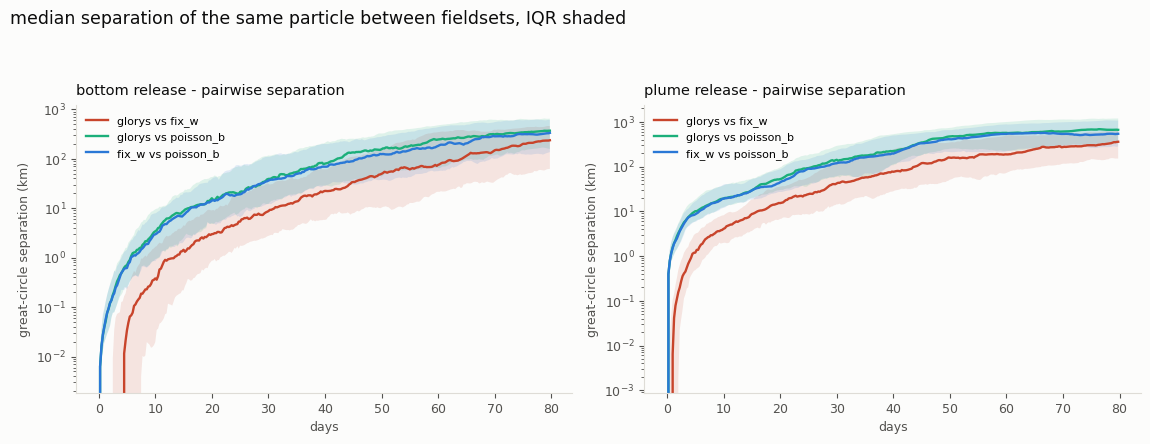

In [9]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})
PC = {("glorys", "fix_w"): "#c8442b", ("glorys", "poisson_b"): "#1baf7a",
      ("fix_w", "poisson_b"): "#2a78d6"}

fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, r in zip(axs, range(len(REGIONS))):
    for (A, B), c in PC.items():
        v = SEP[(A, B)]; s = v["both"] & (TRK[A]["reg"] == r)
        if not s.any(): continue
        km = v["km"][s][:, :full]
        t  = np.arange(km.shape[1]) * out_put_step_hours / 24.0
        ax.plot(t, np.nanmedian(km, axis=0), lw=1.7, color=c, label=f"{A} vs {B}")
        ax.fill_between(t, np.nanpercentile(km, 25, axis=0), np.nanpercentile(km, 75, axis=0),
                        color=c, alpha=0.13, lw=0)
    ax.set_yscale("log")
    ax.set_title(f"{REGIONS[r]} release - pairwise separation", loc="left", fontsize=10.5, pad=8)
    ax.set_xlabel("days"); ax.set_ylabel("great-circle separation (km)")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.suptitle("median separation of the same particle between fieldsets, IQR shaded",
             x=0.005, ha="left", fontsize=12.5, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("v7_separation.png", dpi=160, facecolor=SURF)
plt.show()

## 7. Tracks and depth

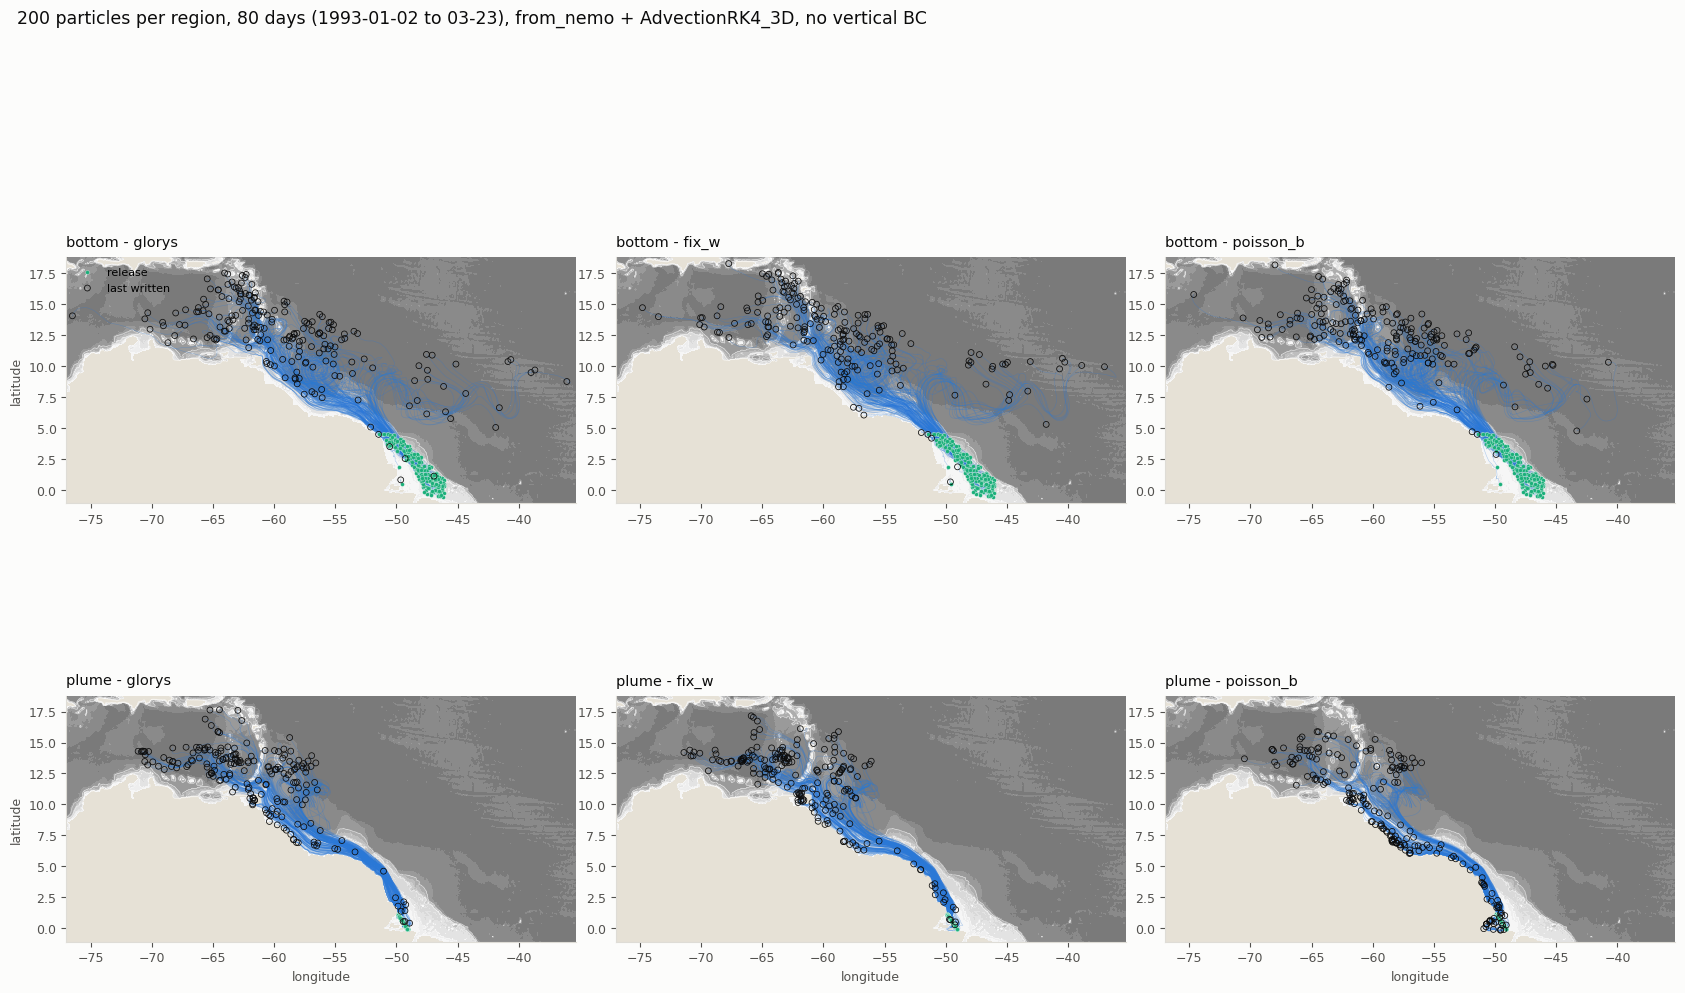

In [10]:
from matplotlib.colors import ListedColormap, BoundaryNorm
allon = np.concatenate([v["lon"].ravel() for v in TRK.values()])
allat = np.concatenate([v["lat"].ravel() for v in TRK.values()])
x0, x1 = np.nanmin(allon) - 0.5, np.nanmax(allon) + 0.5
y0, y1 = np.nanmin(allat) - 0.5, np.nanmax(allat) + 0.5
m = (lon2d >= x0) & (lon2d <= x1) & (lat2d >= y0) & (lat2d <= y1)
gj, gi = np.where(m); Js, Is = slice(gj.min(), gj.max()+1), slice(gi.min(), gi.max()+1)
LEV = [0, 10, 20, 50, 100, 200, 500, 1000, 2000, 4000, 6000]
bc = ListedColormap(mpl.colormaps["Greys"](np.linspace(0.08, 0.6, len(LEV)-1)))
bc.set_bad("#e6e1d6"); bn = BoundaryNorm(LEV, bc.N)
BATH = np.where(mbathy[Js, Is] > 0, H[Js, Is], np.nan)

fig, axs = plt.subplots(len(REGIONS), len(TAGS), figsize=(5.6 * len(TAGS), 5.6 * len(REGIONS)),
                        squeeze=False)
for row, reg in enumerate(REGIONS):
    for col, tag in enumerate(TAGS):
        ax = axs[row, col]; v = TRK[tag]; s = v["reg"] == row
        ax.set_facecolor("#e6e1d6")
        ax.pcolormesh(lon2d[Js, Is], lat2d[Js, Is], BATH, cmap=bc, norm=bn, shading="auto", zorder=0)
        ax.contour(lon2d[Js, Is], lat2d[Js, Is], np.nan_to_num(BATH), levels=[20, 100, 1000],
                   colors="#ffffff", linewidths=0.45, alpha=0.7, zorder=1)
        ax.plot(v["lon"][s].T, v["lat"][s].T, lw=0.4, color="#2a78d6", alpha=0.35, zorder=2)
        ax.scatter(v["lon"][s, 0], v["lat"][s, 0], s=8, color="#1baf7a",
                   edgecolor="white", linewidth=0.2, zorder=4, label="release")
        nb_ = np.isfinite(v["lat"][s]).sum(axis=1)
        lq = np.where(nb_ > 0, nb_ - 1, 0); rq = np.arange(int(s.sum()))
        ax.scatter(v["lon"][s][rq, lq], v["lat"][s][rq, lq], s=18, facecolor="none",
                   edgecolor="#0b0b0b", linewidth=0.55, zorder=5, label="last written")
        lost = int((v["nlive"][s] < full).sum())
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        ax.set_aspect(1 / np.cos(np.deg2rad(np.mean([y0, y1]))))
        ax.set_title(f"{reg} - {tag}" + (f"   ({lost} lost)" if lost else ""),
                     loc="left", fontsize=10.5, pad=8)
        if row == len(REGIONS) - 1: ax.set_xlabel("longitude")
        if col == 0: ax.set_ylabel("latitude")
        if row == 0 and col == 0: ax.legend(frameon=False, fontsize=8, loc="upper left")
        for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.suptitle(f"{n_per_region} particles per region, {run_time_days} days (1993-01-02 to 03-23), "
             "from_nemo + AdvectionRK4_3D, no vertical BC",
             x=0.005, ha="left", fontsize=12.5, color=INK, y=0.997)
fig.tight_layout(rect=[0, 0, 1, 0.968])
fig.savefig("v7_tracks.png", dpi=160, facecolor=SURF)
plt.show()

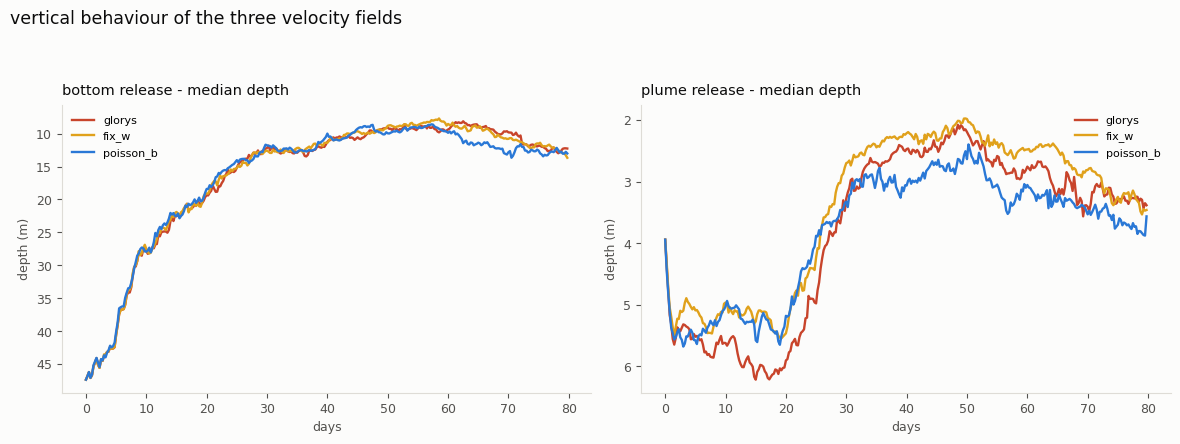

In [11]:
FC = {"glorys": "#c8442b", "fix_w": "#e0a11b", "poisson_b": "#2a78d6"}
fig, axs = plt.subplots(1, len(REGIONS), figsize=(5.9 * len(REGIONS), 4.4))
for ax, r in zip(np.atleast_1d(axs), range(len(REGIONS))):
    for tag in TAGS:
        v = TRK[tag]; s = v["reg"] == r
        zz = v["z"][s][:, :full]
        ax.plot(np.arange(zz.shape[1]) * out_put_step_hours / 24.0,
                np.nanmedian(zz, axis=0), lw=1.7, color=FC[tag], label=tag)
    ax.invert_yaxis()
    ax.set_title(f"{REGIONS[r]} release - median depth", loc="left", fontsize=10.5, pad=8)
    ax.set_xlabel("days"); ax.set_ylabel("depth (m)")
    ax.legend(frameon=False, fontsize=8)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.suptitle("vertical behaviour of the three velocity fields",
             x=0.005, ha="left", fontsize=12.5, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("v7_depth.png", dpi=160, facecolor=SURF)
plt.show()

## 8. Reading the result

Against the three predictions recorded in the header, before the run.

### Prediction 1 - `glorys` loses particles through the surface. **Wrong.**

Zero surface losses in all three runs, and `above surf max = 0.000` everywhere - nothing went
above `z = 0` at all. `glorys`' `W(0)` is real but far too weak to eject anything: `rms
2.1e-07 m/s`, peaking at `3.8e-06 m/s`, and it is an oscillating `deta/dt` term, so it does not
accumulate into a net upward displacement. The broken surface boundary condition is a genuine
defect of the field and a non-event for these trajectories.

### An identity worth noticing

`glorys`' `rms |W(0)|` and its `rms |D|` came out as the same number, `2.126e-07`. That is not
a coincidence: integrating the cell budget upward from the closed seabed makes `W(0)` **equal
to** the column-integrated divergence, so GLORYS' surface residual and its U,V imbalance are
one quantity seen twice.

This reframes what the two corrections do. `Fix_W` drives `W(0)` to exactly zero while leaving
`rms |D|` untouched at `2.126e-07` - it removes the symptom at `z = 0` and leaves the cause.
`poisson_b` attacks the cause, cutting `rms |D|` by three orders of magnitude to `2.2e-10`, and
gets `W(0) = 2.9e-18` for free as a consequence. Only one of the two is a fix to the volume
budget; the other is a fix to its most visible surface.

### Prediction 2 - the W correction is second-order next to U,V. **Partly wrong.**

`glorys` vs `fix_w` differ in W alone and still separate by **237 km** (bottom) and **360 km**
(plume) at day 80 - only a factor 1.6-1.9 below the pairs that also carry the corrected U,V
(369/664 km and 334/543 km). Same order of magnitude, not a smaller one. Changing W alone moves
particles about as far as changing U,V.

### Prediction 3 - scale. Larger than the correction, because the flow is chaotic

Median separations are 14-42% of the ~1600 km the particles travel. But the shape of the curves
in `v7_separation.png` is the real answer: near-exponential growth for the first ~40 days, then
saturation at 300-600 km by day 50-60. That is Lyapunov divergence saturating at the eddy
decorrelation scale. **The separation is set by the chaos of the flow, not by the size of the
correction** - a perturbation of any magnitude would end up at the same saturation value.

Two consequences, and they cut in opposite directions:

- **Individual trajectories are not reproducible across these fieldsets** beyond a few weeks.
  Any per-particle claim from this dataset - where *this* particle beached, which single track
  entered a region - is an artefact of the velocity field chosen.
- **The aggregate statistics are robust.** The median depth histories in `v7_depth.png` lie
  almost on top of each other for all three fields in both releases, as do the loss counts.
  Ensemble and density diagnostics survive the correction; single tracks do not.

It also means **the separation magnitude cannot rank the three fields.** `poisson_b` being
farthest from `glorys` is not evidence that it is better. The case for it rests on the physics -
it is the only one of the three that closes the volume budget its W is meant to represent
(`rms |D|` three orders down) - and on the one trajectory-level difference that is not chaos:

### The one concrete trajectory benefit

Seabed crossings, section 5. `glorys` puts 3 particles through the `k = mbathy` face where the
data itself holds `w = 0` (2 bottom, 1 plume, worst 3.19 m). `fix_w` and `poisson_b` put
**zero**. Both corrections eliminate them; `glorys` alone produces them. Small in count, but
unlike the separations it is a deterministic improvement rather than a saturating divergence.

### Limits

Three fields compared against each other, not against observations, on one 80-day winter
release from two regions. This bounds the sensitivity of the trajectories to the correction and
identifies which quantities survive it. It says nothing on its own about which field is closer
to the real ocean - for that, `poisson_b`'s three-order reduction in `rms |D|` is an argument
from consistency, not from data.